# Linear Regression Model for Medical Charges Prediction

This notebook applies a Linear Regression model to predict medical insurance costs based on customer data such as age, BMI, and smoking statua.

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Understanding the Dataset
The dataset consists of the following columns: age, sex, bmi, children, smoker, region, and charges.

The dataset includes both numerical and categorical variables. After checking for missing values, no missing values were found in the dataset.

In [42]:

df_original = pd.read_csv("insurance.csv")  # keep original data intact


column_descriptions = {
    'age': 'Age of the primary beneficiary',
    'sex': 'Gender of the beneficiary (male/female)',
    'bmi': 'Body Mass Index (weight/height²)',
    'children': 'Number of children covered by health insurance',
    'smoker': 'Smoker status (yes/no)',
    'region': 'Residential area in the US (northeast, southeast, southwest, northwest)',
    'charges': 'Medical charges billed by health insurance'
}


description_table = pd.DataFrame({
    'Column': list(column_descriptions.keys()),
    'Data Type': [df_original[col].dtype for col in column_descriptions.keys()],
    'Description': list(column_descriptions.values())
})

description_table

,Column,Data Type,Description
0,age,int64,Age of the primary beneficiary
1,sex,object,Gender of the beneficiary (male/female)
2,bmi,float64,Body Mass Index (weight/height²)
3,children,int64,Number of children covered by health insurance
4,smoker,object,Smoker status (yes/no)
5,region,object,"Residential area in the US (northeast, southea..."
6,charges,float64,Medical charges billed by health insurance


## Exploratory Data Analysis

The dataset was explored to understand its structure, data types, and summary statistics. No missing values were found. Visualizations show that key variables such as smoking status, BMI, and age have a strong relationship with medical charges, with smoking having the greatest impact.

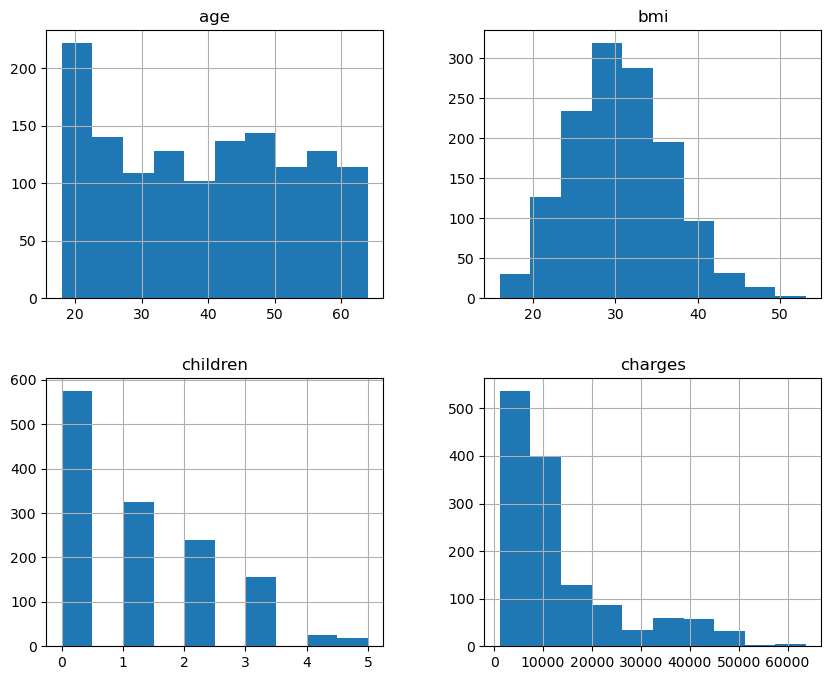

In [9]:
df.hist(figsize=(10,8))
plt.show()

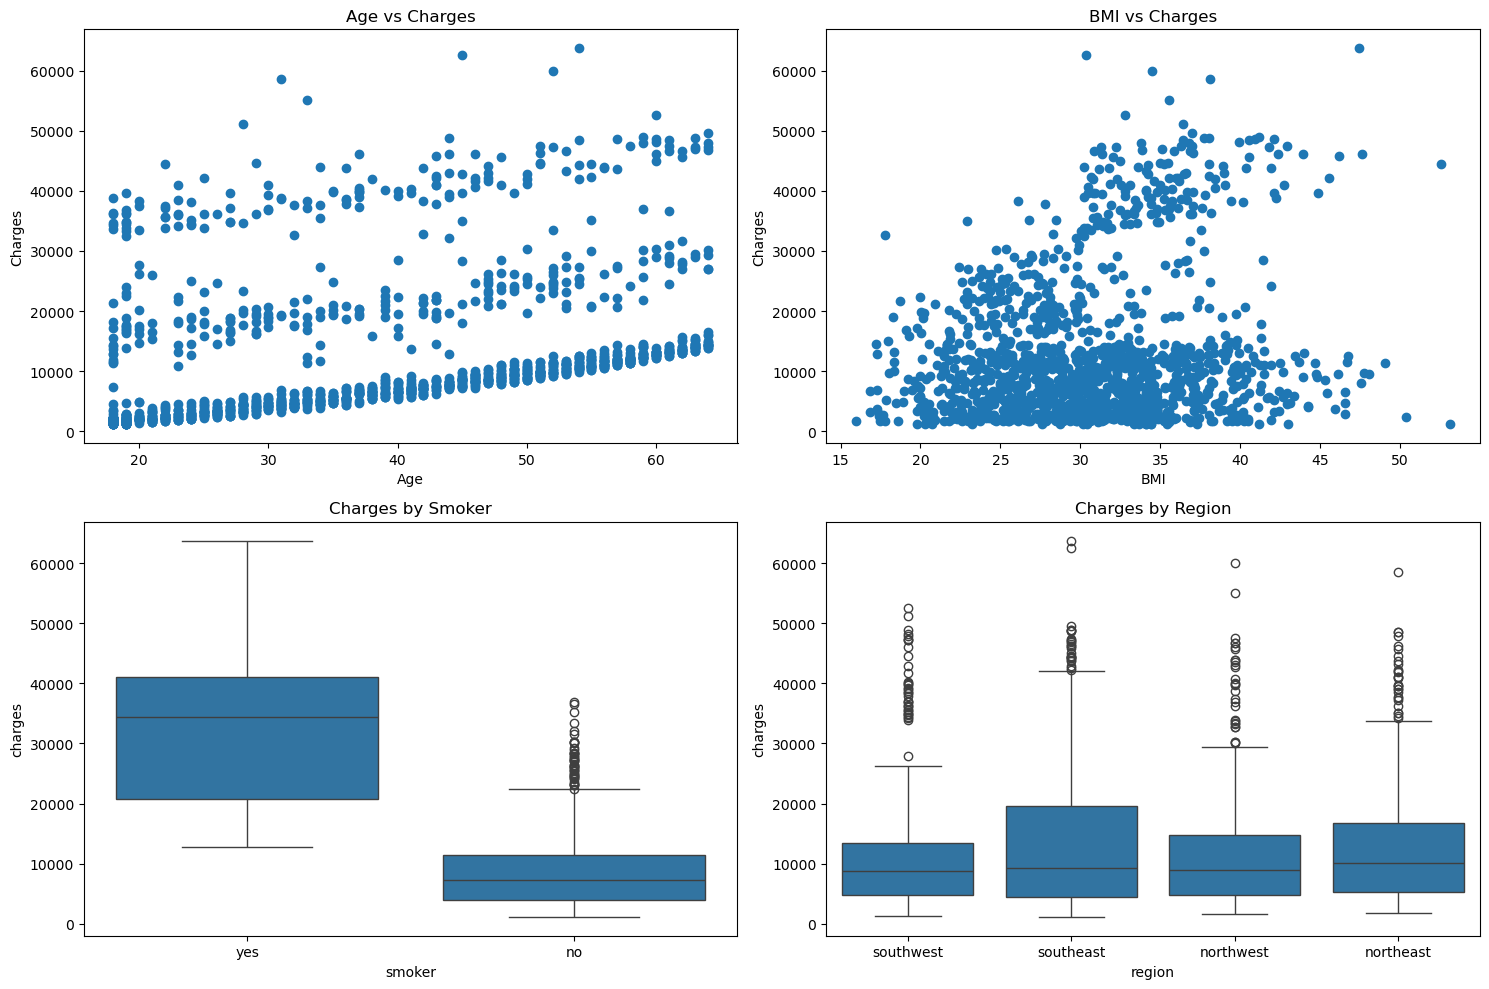

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("insurance.csv")

plt.figure(figsize=(15,10))


plt.subplot(2,2,1)
plt.scatter(df['age'], df['charges'])
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")


plt.subplot(2,2,2)
plt.scatter(df['bmi'], df['charges'])
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")


plt.subplot(2,2,3)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoker")


plt.subplot(2,2,4)
sns.boxplot(x='region', y='charges', data=df)
plt.title("Charges by Region")

plt.tight_layout()
plt.show()

## Data Preparation

Categorical variables were converted into numerical format using one-hot encoding. The dataset was then split into features (X) and target variable (y), followed by a train-test split.

In [13]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


### Define Features and Target 
X contains features: age, bmi, children, encoded categorical columns.
y contains the target: charges.

In [15]:
X = df.drop("charges", axis=1)
y = df["charges"]
X.head()
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

### Split the Data

I split the dataset into training and testing sets.

Training set (80%): Used to train the Linear Regression model.
Testing set (20%): Used to evaluate the model’s performance on unseen data.

This ensures that the model’s predictions are tested on data it hasn’t seen before, which helps prevent overfitting and gives a realistic measure of performance.

In [61]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


print("\nX_train sample:")
display(X_train.head())

print("\ny_train sample:")
display(y_train.head())

X_train shape: (1070, 8)
X_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)

X_train sample:


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,46,19.95,2,False,False,True,False,False
1285,47,24.32,0,False,False,False,False,False
1142,52,24.86,0,False,False,False,True,False
969,39,34.32,5,False,False,False,True,False
486,54,21.47,3,False,False,True,False,False



y_train sample:


560      9193.83850
1285     8534.67180
1142    27117.99378
969      8596.82780
486     12475.35130
Name: charges, dtype: float64

### Training the Linear Regression Model

We train a Linear Regression model using the training set.

In [52]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Making Predictions 

The model predicts medical charges for the test set.

In [55]:
predictions = model.predict(X_test)
predictions[:5]  

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656])

### Model Evaluation
MSE measures average error in predictions.
R² indicates how well the model explains variance in charges.
Higher R² → better model.

In [56]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)

Mean Squared Error (MSE): 33596915.85136146
R-squared (R²): 0.7835929767120723


### Interpretation of Coefficients

Smoking has the largest positive coefficient → biggest increase in costs.
BMI and age also increase charges.
Useful for understanding which factors most influence medical costs.

In [57]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
coefficients

,Feature,Coefficient
0,age,256.975706
1,bmi,337.092552
2,children,425.278784
3,sex_male,-18.591692
4,smoker_yes,23651.128856
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354
